In [96]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as utils
import sys,os
import torch
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/")
from nflows.flows.base import Flow, ChainedFlow
from nflows.flows.autoregressive import MaskedAutoregressiveFlow
from nflows.distributions.normal import StandardNormal, ConditionalDiagonalNormal, FullNormal, Exp
from nflows.distributions.uniform import BoxUniform
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform, MaskedPiecewiseQuadraticAutoregressiveTransform, MaskedPiecewiseRationalQuadraticAutoregressiveTransform
from nflows.transforms.autoregressive import ConditionalRationalQuadraticAutoregressiveTransform, RQS1D
from nflows.transforms.nonlinearities import IntervalToReals
from nflows.transforms.permutations import ReversePermutation
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/finalTraining")
import trainingTools as tools
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

def make_flow(n_features,initial_tb,n_context=0,n_layers=5,hidden_features=64,num_bins=40,num_blocks=2,k=8.0):
    tail_bound = [[initial_tb[0],initial_tb[1],-k,k]]+[[-k,k,-k,k]]*(n_layers-1)
    tails='linear'
    base_dist = StandardNormal(shape=[n_features])
    transforms = []
    parity = 1
    if n_context == 0:
        num_context = None
    else:
        num_context = n_context
    for i in range(n_layers):
        transforms.append(
            MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
                features = n_features,
                hidden_features = hidden_features,
                context_features=num_context,
                num_bins = num_bins,
                num_blocks = num_blocks,
                tail_bound = tail_bound[i],
                tails = tails
            )
        )
    #transforms.append(IntervalToReals(left=-k,right=k))
    transforms = CompositeTransform(transforms)
    flow = Flow(transforms,base_dist)
    return flow

def make_flow_v2(n_features,initial_tbs,n_context=0,n_layers=5,hidden_features=64,num_bins=40,num_blocks=2,k=8.0):
    tail_bound = [[[tb[0]-0.1,tb[1]+0.1,-k,k] for tb in initial_tbs]] + [k]*(n_layers-1)
    tails=['multi_linear']+['linear']*(n_layers-1)
    base_dist = StandardNormal(shape=[n_features])
    transforms = []
    parity = 1
    if n_context == 0:
        num_context = None
    else:
        num_context = n_context
    for i in range(n_layers):
        transforms.append(
            MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
                features = n_features,
                hidden_features = hidden_features,
                context_features=num_context,
                num_bins = num_bins,
                num_blocks = num_blocks,
                tail_bound = tail_bound[i],
                tails = tails[i]
            )
        )
    transforms.append(IntervalToReals(left=-k,right=k))
    transforms = CompositeTransform(transforms)
    flow = Flow(transforms,base_dist)
    return flow

def make_conditional_flow(n_features,initial_tb,n_context=0,n_layers=5,hidden_features=128,num_bins=40,num_blocks=2,k=8.0):
    tail_bound = [[initial_tb[0],initial_tb[1],-k,k]]+[[-k,k,-k,k]]*(n_layers-1)
    tails='linear'
    base_dist = StandardNormal(shape=[n_features])
    transforms = []
    parity = 1
    for i in range(n_layers):
        transforms.append(
            ConditionalRationalQuadraticAutoregressiveTransform(
                features = n_features,
                context_features = n_context,
                hidden_features = hidden_features,
                num_bins = num_bins,
                num_blocks = num_blocks,
                tail_bound = tail_bound[i],
                tails = tails
            )
        )
    #transforms.append(IntervalToReals(left=-k,right=k))
    transforms = CompositeTransform(transforms)
    flow = Flow(transforms,base_dist)
    return flow

def make_1d_flow(initial_tb,n_layers=5,num_bins=40,k=8.0):
    tail_bound = [[initial_tb[0],initial_tb[1],-k,k]]+[[-k,k,-k,k]]*(n_layers-1)
    tails='linear'
    base_dist = StandardNormal(shape=[1])
    #base_dist = BoxUniform(low=-k,high=k,reinterpreted_batch_ndims=0)
    transforms = []
    for i in range(n_layers):
        if type(num_bins)==list:
            nb = num_bins[i]
        else:
            nb = num_bins
        transforms.append(
            RQS1D(
                num_bins=nb,
                tails=tails,
                tail_bound=tail_bound[i],
            )
        )
    #transforms.append(IntervalToReals(left=-k,right=k))
    transforms = CompositeTransform(transforms)
    flow = Flow(transforms,base_dist)
    return flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
#variables = ['jet1_rho','jet1_logTauS','jet1_tau21','jet1_npf','jet1_tau32','jet1_tau43','jet1_pb']
#variables = ['jet1_rho','jet1_logTauS','jet1_tau21']
variables = ['jet1_rho']
train = tools.loadData("QCDBKG_mjjFlat",2017,variables,100000)
mean,std = tools.loadMeans("QCDBKG",2017,variables)
train = (train-mean)/std
train = train.astype('float32')

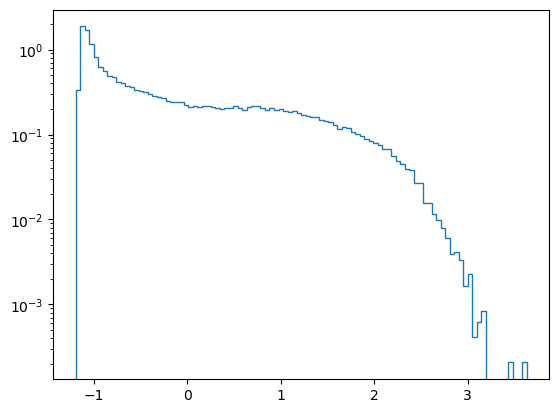

In [98]:
h = plt.hist(train,histtype='step',density=True,bins=100)
plt.yscale('log')

In [99]:
mins = train.min(axis=0)
maxes = train.max(axis=0)
tbs = [[float(np.floor(mins[i])),float(np.ceil(maxes[i]))] for i in range(len(mins))]
tbs

[[-2.0, 4.0]]

In [192]:
#flow = make_flow_v2(len(variables),tbs,n_layers=10,hidden_features=250,num_bins=40,num_blocks=4,k=10.0)
#flow1 = make_flow(1,tbs[0],n_context=0,n_layers=5,hidden_features=128,num_bins=40,num_blocks=4,k=8.0)
#flows = [flow1]
#for i in range(1,len(variables)):
#    print([float(np.floor(mins[i])),float(np.ceil(maxes[i]))])
#    flows.append(make_conditional_flow(1,tbs[i],n_context=i,n_layers=5,hidden_features=128,num_blocks=4,num_bins=40,k=8.0))
#flow = ChainedFlow(flows)
flow = make_1d_flow([-1.2,4],n_layers=2,num_bins=150,k=5.0)

Iteration 10 Complete
Loss:  5.517259120941162
Iteration 20 Complete
Loss:  4.417545318603516
Iteration 30 Complete
Loss:  3.35506010055542
Iteration 40 Complete
Loss:  2.4738080501556396
Iteration 50 Complete
Loss:  1.8743458986282349
Iteration 60 Complete
Loss:  1.601091980934143
Iteration 70 Complete
Loss:  1.3939263820648193
Iteration 80 Complete
Loss:  1.235761046409607
Iteration 90 Complete
Loss:  1.151703119277954
Iteration 100 Complete
Loss:  1.0732442140579224
Iteration 110 Complete
Loss:  1.0354005098342896
Iteration 120 Complete
Loss:  1.0143018960952759
Iteration 130 Complete
Loss:  0.9937525987625122
Iteration 140 Complete
Loss:  0.9722446203231812
Iteration 150 Complete
Loss:  0.9652134776115417
Iteration 160 Complete
Loss:  0.9579071998596191
Iteration 170 Complete
Loss:  0.9435474276542664
Iteration 180 Complete
Loss:  0.9411066174507141
Iteration 190 Complete
Loss:  0.9373175501823425


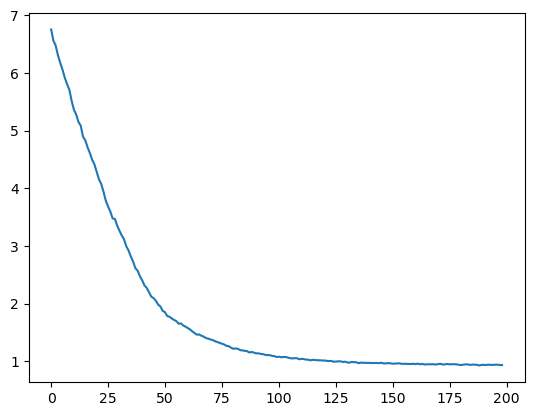

In [193]:
trainData = torch.tensor(train,device=device)
ntrain = len(train)
#optimizer = optim.Adam(list(flow1.parameters())+list(flow2.parameters()),lr=5e-4)
optimizer = optim.Adam(flow.parameters(),lr=1e-3)

min_loss = 1e+8
train_losses = []
patience_count = 0
print_interval=10
n_epoch=200
patience=10
bs = 10000

for i in range(n_epoch):
    perm = torch.randperm(ntrain)
    perms = torch.split(perm,bs)
    if patience_count == patience:
        break
    epoch_losses = []
    for batch_idx, p in enumerate(perms):
        x = trainData[p]
        optimizer.zero_grad()
        #loss = -(flow1.log_prob(inputs=x[:,:1])[0] + flow2.log_prob(inputs=x[:,1:],context=x[:,:1])[0]).mean()
        loss = -flow.log_prob(inputs=x)[0].mean()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        if loss.item() < min_loss:
            min_loss = loss.item()
            #torch.save(flow1.state_dict(),"flow1.pt")
            #torch.save(flow2.state_dict(),"flow2.pt")
            torch.save(flow.state_dict(),"flow.pt")
    epoch_loss = np.min(epoch_losses)
    train_losses.append(epoch_loss)
    if (i + 1) % print_interval == 0:
        print('Iteration {} Complete'.format(i + 1))
        print('Loss: ', epoch_loss)
    if epoch_loss == min_loss:
        patience_count = 0
    else:
        patience_count += 1
plt.plot(np.arange(len(train_losses)),train_losses)

In [194]:
flow.load_state_dict(torch.load('flow.pt'))
with torch.no_grad():
    sample_target = flow.sample(10000)

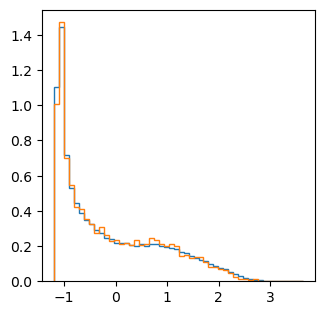

In [195]:
plt.figure(figsize=(12,12))
for i in range(train.shape[1]):
    plt.subplot(3,3,i+1)
    h2,bins,_ = plt.hist(train[:,i],bins=50,histtype='step',density=True)
    h1 = plt.hist(sample_target.detach().cpu().numpy()[:,i],bins=bins,histtype='step',density=True)

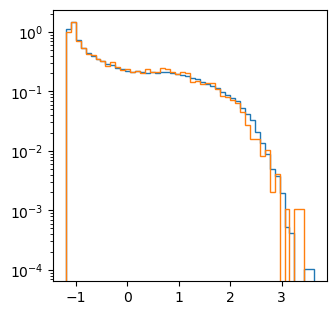

In [196]:
plt.figure(figsize=(12,12))
for i in range(train.shape[1]):
    plt.subplot(3,3,i+1)
    h2,bins,_ = plt.hist(train[:,i],bins=50,histtype='step',density=True)
    h1 = plt.hist(sample_target.detach().cpu().numpy()[:,i],bins=bins,histtype='step',density=True)
    plt.yscale('log')

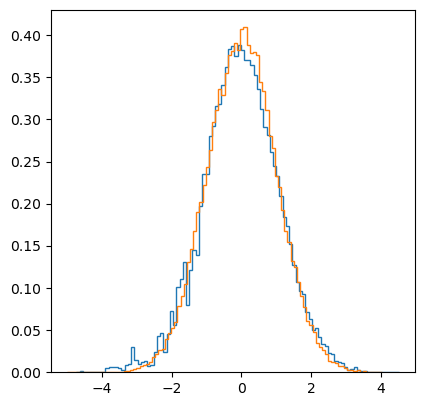

In [197]:
plt.figure(figsize=(16,16))
with torch.no_grad():
    noise = flow.transform_to_noise(trainData)
k = noise.detach().cpu().numpy()
for i in range(len(variables)):
    plt.subplot(3,3,i+1)
    nsamp = len(k[:,i])
    h1 = plt.hist(k[:,i],bins=100,histtype='step',density=True)
    samples = np.random.normal(size=nsamp)
    h2 = plt.hist(samples,histtype='step',density=True,bins=100)

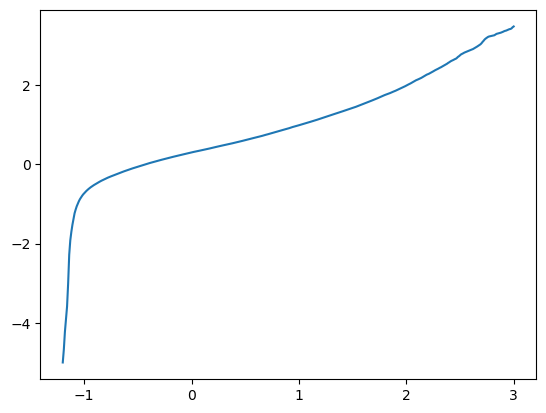

In [198]:
test = torch.arange(-1.2,3.01,0.01).reshape(-1,1)
y = flow.transform_to_noise(test).detach().cpu().numpy()[:,0]
x = test.cpu().numpy()[:,0]
plt.plot(x,y)

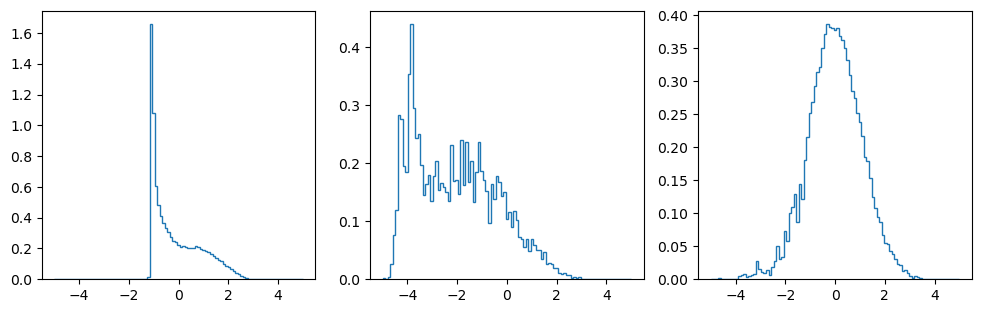

In [199]:
plt.figure(figsize=(12,16))
plt.subplot(4,3,1)
bins = np.linspace(-5,5,100)
h=plt.hist(train,density=True,histtype='step',bins=bins)
test = trainData
for i,tf in enumerate(flow._transform._transforms):
    plt.subplot(4,3,i+2)
    test = tf(test)[0]
    h=plt.hist(test.detach().cpu().numpy()[:,0],density=True,histtype='step',bins=bins)